# bayesld

`bayesld` is a Python package for Bayesian inference of very recent demography.

## Motivation

This notebook presents a comprehensive analysis of a very recent bottleneck using simulated data. Working with simulated data here serves a double purpose. First, we use it to conduct a full analysis and illustrate the main usage of bayesld. Second, this notebook can be adapted to other scenarios to perform (1) a verification step and (2) a power analysis. `bayesld` falls within the scope of model-based inference, which means that for a given demography we can simulate a dataset, and for a given dataset we can obtain parameters. It is unreasonable to trust a demographic model that does not work even on simulated data, so we advise verifying your model first (the verification step). It is also extremely useful to study a priori the effect of adding more samples to an analysis or, for example, how large a population in decline must be, or for how long it must decline, before it can be detected (power analysis).

## Ecosystem

This package relies on msprime, a well-established population genetics simulator, and ArviZ, a language-agnostic ecosystem for statistics, visualization, and diagnostics in Bayesian workflows. Both libraries have extensive documentation and capabilities far beyond what we use here.

In [1]:
import bayesld
import msprime
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Case study: a very recent bottleneck

Consider a relatively small population that undergoes an instantaneous change in size 30 generations ago:

In [2]:
true_params = {
    # ancestral population size
    "Ne_a": 4000,
    # bottleneck strength
    "decline_fraction": 0.65,
    # generations ago
    "time_bottleneck": 30,
}

We define an [msprime](https://tskit.dev/msprime/docs/stable/demography.html) demographic model with the true parameters:

In [3]:
true_demography = msprime.Demography()
true_demography.add_population(
    initial_size=true_params["decline_fraction"] * true_params["Ne_a"]
)
true_demography.add_population_parameters_change(
    time=true_params["time_bottleneck"],
    initial_size=true_params["Ne_a"],
)
true_demography

Demography(populations=[Population(initial_size=2600.0, growth_rate=0, name='pop_0', description='', extra_metadata={}, default_sampling_time=None, initially_active=None, id=0)], events=[PopulationParametersChange(time=30, initial_size=4000, growth_rate=None, population=-1)], migration_matrix=array([[0.]]))

Optionally, we can visualize it using `demesdraw` (especially useful for more complex scenarios):

<Axes: xlabel='time ago (generations)', ylabel='deme\nsize'>

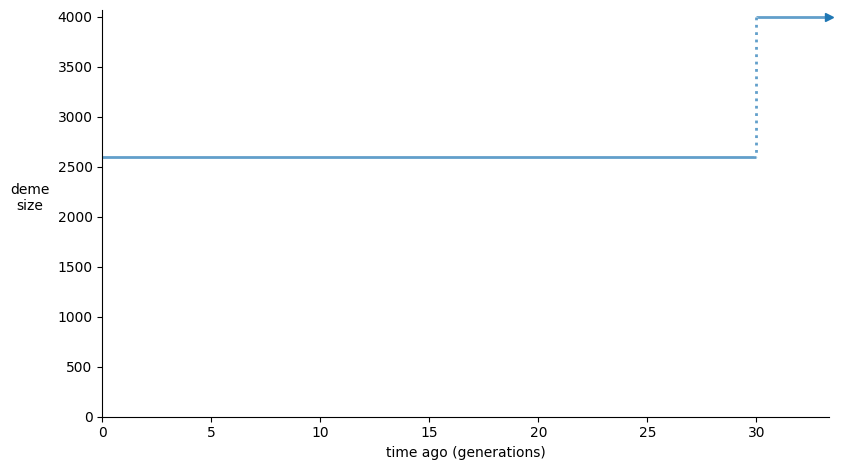

In [4]:
import demesdraw

demesdraw.size_history(true_demography.to_demes())

## Dataset

`bayesld` performs inference over a set of informative summary statistics computed across windows (which are assumed to be independent and identically distributed). These statistics are the mean observed genetic diversity (also known as sample heterozygosity) and a measure of linkage disequilibrium (LD). To measure LD, we compute $\overline{X_i X_j Y_i Y_j}$, the mean product of the (centered and standardized) genotypes across all pairs of individuals, for many pairs of loci $X$ and $Y$ separated by increasing distances. Pairs of genotypes are then aggregated in different bins.

Both summary statistics can be computed from an unphased VCF, provided that estimates of the recombination rate and mutation rate are available. The package provides utilities to extract this information from a real VCF, either from the command line or through the Python API (see `bayesld.data_from_vcf`). Both use cases are covered in a separate tutorial ([data_from_vcf.md](data_from_vcf.md)).

Here we work with simulated data, so we can skip creating an intermediate VCF and use the function `bayesld.sim_sufficient_stats` instead. Internally, this function wraps `msprime.sim_ancestry`, `msprime.sim_mutations`, and `bayesld.data_from_tree_sequence` (the last of which you can use directly if you simulated your data with a different engine, such as SLiM).

### Binning scheme

Any binning scheme can be used. Here, we use the default settings:

In [5]:
left_bins_morgan, right_bins_morgan = bayesld.linear_bins()
midpoints = (left_bins_morgan + right_bins_morgan) / 2
midpoints

array([0.0075, 0.0125, 0.0175, 0.0225, 0.0275, 0.0325, 0.0375, 0.0425,
       0.0475, 0.0525, 0.0575, 0.0625, 0.0675, 0.0725, 0.0775, 0.0825,
       0.0875, 0.0925, 0.0975])

### Sample size and genomic windows

Resolving the very recent past often requires large sample sizes. Here we simulate a moderately large sample of 30 diploid individuals across 100 genomic windows of 20 cM each (corresponding to 20 chromosomes of 1 Morgan). I further assume a mutation rate and recombination rate of 1e-8.

In [6]:
mutation_rate = 1e-8
recombination_rate = 1e-8
window_length_in_morgan = 0.20
window_length_in_bp = window_length_in_morgan / recombination_rate
num_samples = 30
num_windows = 100

# Sanity check: the genomic window must be larger than the largest bin
assert np.all(window_length_in_morgan > right_bins_morgan), "Decrease bin distances!"

We are ready to simulate the dataset:

In [7]:
obs_pi, obs_ld = bayesld.sim_sufficient_stats(
    demography=true_demography,
    samples=num_samples,
    left_bins=left_bins_morgan,
    right_bins=right_bins_morgan,
    mutation_rate=mutation_rate,
    recombination_rate=recombination_rate,
    sequence_length=window_length_in_bp,
    random_seed=216789,
    num_replicates=num_windows,
    model="hudson",
    num_workers=8,
)

Next, we visualize the simulated dataset (our "empirical" dataset). As expected, we observe, on average, a decay of LD as a function of the genetic distance between pairs of SNPs. Error bars show the standard error of the observed mean.

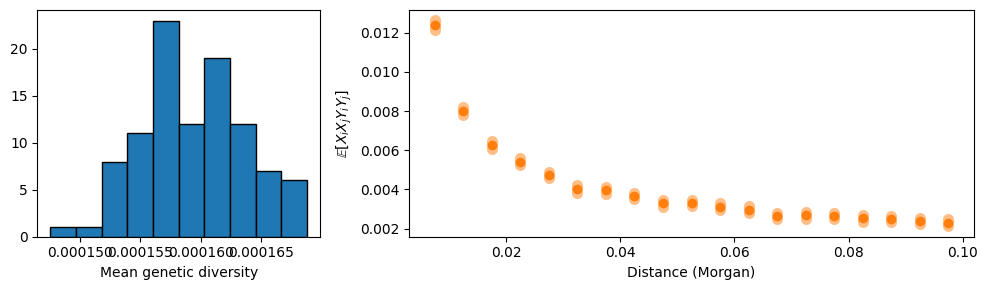

In [8]:
fig, (ax_pi, ax_ld) = plt.subplots(
    1, 2, figsize=(10, 3), gridspec_kw={"width_ratios": [3, 6]}
)
ax_pi.hist(obs_pi, color="C0", edgecolor="black")
ax_pi.set_xlabel("Mean genetic diversity")
_mean = obs_ld.mean(axis=0)
_stderr = obs_ld.std(axis=0) / np.sqrt(num_windows)
ax_ld.vlines(
    midpoints,
    _mean - _stderr,
    _mean + _stderr,
    capstyle="round",
    linewidth=8,
    alpha=0.5,
    color="C1",
)
ax_ld.plot(midpoints, obs_ld.mean(axis=0), "o", color="C1")
ax_ld.set_xlabel("Distance (Morgan)")
ax_ld.set_ylabel(r"$\mathbb{E}[X_i X_j Y_i Y_j]$")
plt.tight_layout()
plt.show()

## Fitting the first model: constant size

It is often recommended to start with a simpler model and iteratively fit more complex ones. A reasonable first choice is a constant-size demography. If it fits well, that may suggest the focal population is at equilibrium and has not been affected by any recent demographic disturbance.

A constant-size demography can be modelled as a `PiecewiseConstant` with a single epoch. Let's instantiate a model and pass it our empirical dataset via the `.with_data` method. The first time you instantiate a model it will transpile it into C++ and compile it (using Stan).

In [9]:
from bayesld.inference import PiecewiseConstant

constant_model = PiecewiseConstant(num_epochs=1).with_data(
    mean_diversity=obs_pi,
    mean_ld=obs_ld,
    left_bins=left_bins_morgan,
    right_bins=right_bins_morgan,
    recombination_rate=recombination_rate,
    mutation_rate=mutation_rate,
    num_samples=num_samples,
    sequence_length=window_length_in_bp,
)

Inside a Jupyter (or marimo) notebook, we can get an overview of the different parts of the model by simply returning it as the last expression in a cell. Next, we go through the main elements that make up the model.

In [10]:
constant_model

PiecewiseConstant(Epochs=1, Quadrature nodes=8, Windows=100, LD bins=19, Samples=30 (ploidy 2), Sequence length=2e+07, Mutation rate=1e-08, Recombination rate=1e-08, Bias dataset=0, Covariance dataset=100+0)

Any Bayesian model consists of a prior ($P(\theta)$) and a likelihood probability distribution ($P(\text{Data} \mid \theta)$). Doing computational Bayesian inference means to approximate a target posterior

$$
P(\theta \mid \text{Data}) \propto P(\text{Data} \mid \theta)\, P(\theta) 
$$

This probability density is approximated using Markov Chain Monte Carlo (or MCMC). 

#### The prior

Here, the prior is a probability distribution assigned to the parameters of the chosen parametric form $N_e(t)$ (that is, a probability distribution over a "family" of demographies). `PiecewiseConstant` places a [log-normal](https://en.wikipedia.org/wiki/Log-normal_distribution) prior on $N_e$ (which conveniently forces the parameter to stay positive). For a single epoch this means:

$$
\begin{align}
N &\sim \text{LogNormal}(\mu_N, \sigma_N), \\
N_e(t) &= N.
\end{align}
$$

where $\mu_N$ and $\sigma_N$ are specified by the user through the `.with_prior` method.

By default, we estimate a prior from the data (often called an [empirical Bayes prior](https://en.wikipedia.org/wiki/Empirical_Bayes_method)). We can inspect it by first drawing samples from the prior (with the `.sample_prior` method). The output is an `xarray.DataTree` (the rich data structure used by ArviZ), so we can explore it using the extensive tooling that ArviZ provides.

In [11]:
prior_constant = constant_model.sample_prior(draws=4000, chains=2, seed=32167)
az.summary(prior_constant, kind="stats")

,mean,sd,eti89_lb,eti89_ub
log_Ne[0],8.3,1.5,5.9,11
Ne_values[0],12000,32000,360,45000


In this case, the default prior is very uninformative, with an 89% credible interval covering a wide range of 360–45000 diploid individuals. Let's continue with it.

#### The (surrogate) likelihood

Here, the likelihood is a probability distribution assigned to the observed data. That is, a probability distribution for the windowed mean summary statistics. If genomic windows are large enough and contain many [SNPs](https://en.wikipedia.org/wiki/Single-nucleotide_polymorphism), this distribution is well approximated by a [multivariate normal distribution](https://en.wikipedia.org/wiki/Multivariate_normal_distribution).

`bayesld` combines (biased) analytical predictions and (unbiased) Monte Carlo simulations to **jointly** learn the form of the likelihood (i.e. a surrogate likelihood) together with the posterior probability of the parameters.

#### Active learning rounds

Learning the surrogate likelihood involves *augmenting* the empirical dataset with Monte Carlo estimates of the log-likelihood. In practice, a few dozen parameter combinations in the region of high posterior probability are enough. Of course, we don't know where that region is before fitting the model. To avoid wasting time/resources, `bayesld` uses a sequence of active learning rounds: we fit the model with increasingly better approximations of the log-likelihood and augment the empirical dataset with high-probability parameter combinations.

The cost of each Monte Carlo estimate grows with the population's effective size. On the bright side, the initial analytical approximation is also better at high $N_e$. This means that, to keep the error acceptable, many simulations are needed when they are cheap, whereas when they are expensive only a small number (or none) are needed.

#### Posterior distribution for a constant model

As promised, we now fit the constant demography (remember, to a population that has experienced a bottleneck).

I will perform 2 rounds of active learning with 20 points each. Increasing the number of points and decreasing `rtol` might increase the _confidence_ of the joint model in the surrogate likelihood and result in better posterior estimates (at the cost of a higher runtime). I recommend choosing a value smaller than 0.1 if you have many cores.

The package API is designed to be flexible enough so you can split computation across different runs or machines (for example, maximizing parallelism in an HPC, whereas running MCMC in a local laptop). If you want to save the model and continue later, you can just save it using `pickle`.

In [12]:
%%time 
for i in range(2):
    constant_model = constant_model.active_learning_round(
        num_points=20,
        rtol=0.10,
        min_replicates=50,
        verbose=False,
        num_workers=8,
        seed=2178,
    )
constant_model

CPU times: user 3.83 s, sys: 586 ms, total: 4.42 s
Wall time: 3min 25s


PiecewiseConstant(Epochs=1, Quadrature nodes=8, Windows=100, LD bins=19, Samples=30 (ploidy 2), Sequence length=2e+07, Mutation rate=1e-08, Recombination rate=1e-08, Bias dataset=40, Covariance dataset=100+20)

After active learning, we sample from the (surrogate) posterior using NUTS (a particular MCMC algorithm).

In [13]:
posterior_constant = constant_model.sample(
    draws=1000, num_workers=4, chains=4, seed=32167, verbose=False
)

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

From the ArviZ package, we have a variety of opinionated tools to diagnose MCMC convergence. As a rule of thumb, we aim for an $\hat r < 1.01$ and an effective sample size (`ess`) greater than 400. In this case, the MCMC chains have explored the parameter space without problems.

In [14]:
az.summary(posterior_constant, var_names="Ne_values", kind="diagnostics")

,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Ne_values[0],3579,2590,1.00,0.16,0.11


Alternatively, we may plot the so-called trace plot and verify that the output looks like a fuzzy caterpillar.

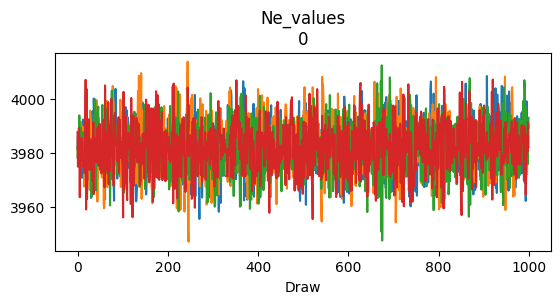

In [15]:
az.plot_trace(posterior_constant, var_names="Ne_values");

If we directly inspect the distribution of the estimated $N_e$, we observe an estimate close to 4000 diploid individuals. This value is very close to the ancestral size (`Ne_a`) and overestimates the contemporary bottleneck size (2600.0 diploids).

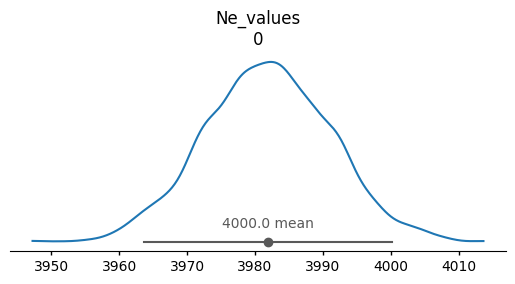

In [16]:
az.plot_dist(posterior_constant, var_names="Ne_values", ci_prob=0.95);

Because model-based inference has a generative model, we can compare the observed data with new predictions simulated under the fitted model. By comparing them we evaluate the absolute goodness of fit of the model. Large deviations are a sign of severe model misspecification. In Bayesian jargon, this is known as posterior predictive checks.

We will repeat this plot several times, so let's define a function that plots the observed data together with the posterior predictive distribution.

In [17]:
def plot_posterior_predictive(idata, colors=("black", "C0")):
    obs = idata["observed_data"]
    ppc = idata["posterior_predictive"]
    midpoints = idata["constant_data"]["midpoint"]
    color_obs, color_pred = colors

    fig, (ax_pi, ax_ld) = plt.subplots(1, 2, figsize=(11, 4))

    post_pi = ppc["observed_pi"].stack(sample=("chain", "draw"))
    pred_ld = ppc["observed_ld"].mean(dim="window").stack(sample=("chain", "draw"))
    n_post = post_pi.sizes["sample"]
    sample_idx = np.linspace(0, n_post - 1, min(50, n_post), dtype=int)

    for i, idx in enumerate(sample_idx):
        sns.kdeplot(
            post_pi.isel(sample=idx),
            color=color_pred,
            alpha=0.3,
            linewidth=1,
            ax=ax_pi,
            cut=0,
            label="Predicted" if i == 0 else None,
        )
    sns.kdeplot(obs["observed_pi"], color=color_obs, ax=ax_pi, cut=0, label="Observed")
    pi_vals = np.concatenate(
        [obs["observed_pi"].values, post_pi.isel(sample=sample_idx).values.ravel()]
    )
    ax_pi.set_xticks([])
    ax_pi.set_xlabel(r"Genetic diversity ($\pi$)")
    ax_pi.legend()

    for i, idx in enumerate(sample_idx):
        ax_ld.plot(
            midpoints,
            pred_ld.isel(sample=idx),
            alpha=0.1,
            color=color_pred,
            label="Predicted" if i == 0 else None,
        )
    ax_ld.plot(midpoints, obs["mean_ld"], color=color_obs, label="Observed")
    ax_ld.set_xlabel("Genetic distance (Morgan)")
    ax_ld.set_ylabel(r"Linkage disequilibrium ($\mathbb{E}[X_i X_j Y_i Y_j]$)")
    ax_ld.legend()

    fig.tight_layout()
    return fig

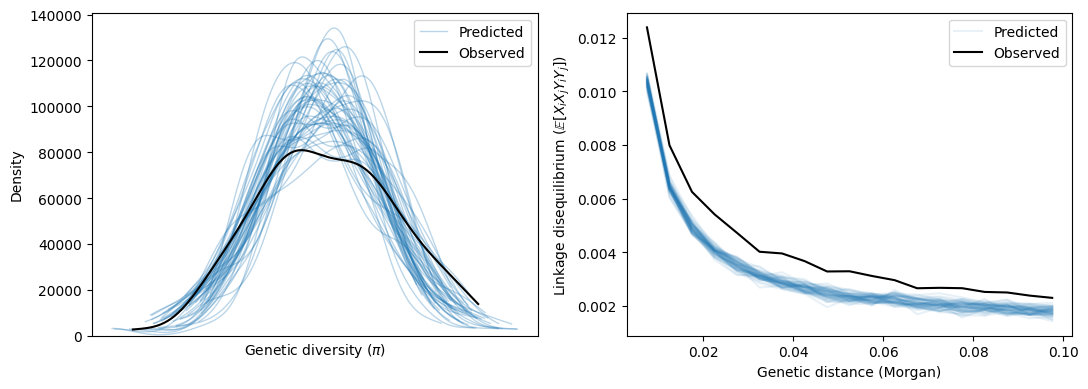

In [18]:
plot_posterior_predictive(posterior_constant);

From the fitted model, we can simulate new datasets and plot the (posterior predictive) distribution of any summary statistics. Ideally, we should not be able to tell them apart (other than because the observed data point is coloured in black). For this model, the absolute goodness of fit is bad, and we observe a positive bias in the predicted LD pattern. 

This is expected: the real data is undergoing a bottleneck, and as such experiences higher drift (and lower $N_e$). A stronger bottleneck would accentuate the bias. In other words, there's no constant $N_e$ value that's consistent with both the observed genetic diversity and LD pattern. 

<details>
  <summary>More on posterior predictive checks</summary>
    I've found the mean to be informative of model misspecification in this model. However, it is often useful to look at the entire distribution across windows. We can use `az.plot_ppc_dist`.

    Try running 

    ```python
    az.plot_ppc_dist(posterior_constant, cols=["bin"], var_names="observed_ld")
    ```
</details>

## Fitting a two-epoch model

The posterior predictive checks revealed that a `constant` demography was not a good fit for this dataset. Next, I will fit a two-epoch piecewise constant model (which, in this case, corresponds to the actual demography).

In [19]:
two_epoch_model = PiecewiseConstant(num_epochs=2).with_data(
    mean_diversity=obs_pi,
    mean_ld=obs_ld,
    left_bins=left_bins_morgan,
    right_bins=right_bins_morgan,
    recombination_rate=recombination_rate,
    mutation_rate=mutation_rate,
    num_samples=num_samples,
    sequence_length=window_length_in_bp,
)

Rather than going with the default prior, I will specify one using the `.with_prior` method. How to specify priors is a big topic in Bayesian inference. Priors can be chosen from the literature (for example, from a meta-analysis of previous demographic analyses) to reflect _a priori_ knowledge. That is called an informative prior.

Suppose in this case we are aiming to model a known bottleneck (because of ecological data). It might make sense to choose a prior that reflects that knowledge. However, it is often recommended to use so-called weakly informative priors: a prior that sets most probability mass only on biologically realistic scenarios while allowing the data to contradict our domain knowledge (as that can indicate a bug in the code or model misspecification).

Here, I set weakly informative priors that are consistent with either a recent growth or decrease in $N_e$.

$$
\begin{align}
N_c &\sim \text{LogNormal}(\log(10000), 1), \\
N_a &\sim \text{LogNormal}(\log(10000), 1), \\
t_0 &\sim \text{LogNormal}(\log(100), 1), \\
N_e(t) &=
\begin{cases}
N_c, & t < t_0, \\
N_a, & t \geq t_0.
\end{cases}
\end{align}
$$

In [20]:
two_epoch_model = two_epoch_model.with_prior(
    mu_log_ne=np.log([10_000, 10_000]),
    sigma_log_ne=np.array([1.0, 1.0]),
    mu_log_t=np.log([100]),
    sigma_log_t=np.array([1.0]),
)
two_epoch_model

PiecewiseConstant(Epochs=2, Quadrature nodes=8, Windows=100, LD bins=19, Samples=30 (ploidy 2), Sequence length=2e+07, Mutation rate=1e-08, Recombination rate=1e-08, Bias dataset=0, Covariance dataset=100+0)

It is always a good idea to examine the implications of the prior. As before, we can sample a set of draws from the prior.

In [21]:
prior_2epoch = two_epoch_model.sample_prior()
az.summary(prior_2epoch, kind="stats")

,mean,sd,eti89_lb,eti89_ub
log_Ne[0],9.2,1,7.5,11
log_Ne[1],9.3,0.97,7.7,11
Ne_values[0],16000,20000,1800,46000
Ne_values[1],18000,25000,2200,47000
log_t[0],4.6,0.98,3.1,6.1
t_boundaries[0],160,240,21,460


As demographic models become more complex, it becomes more useful to plot the implications of the parameters rather than look at tables. We can use the `.plot_demography` function for that.

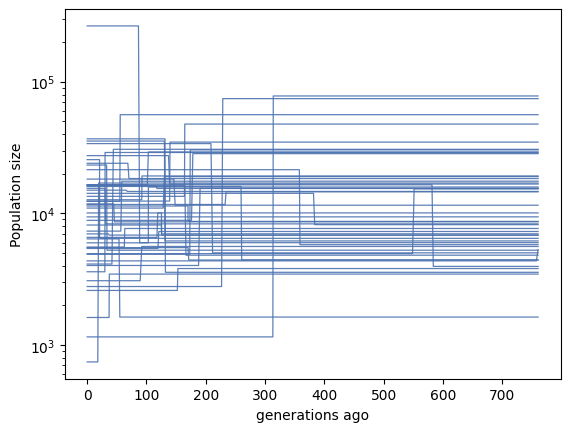

In [22]:
_samples = az.extract(prior_2epoch, num_samples=50, random_seed=1)
two_epoch_model.plot_demography(_samples);

The prior seems broad enough for our purpose, although it sets a high probability density of changes in $N_e$ happening a few hundred generations ago. However, this will not affect our results here. Additionally, one can use the `.to_msprime_demography` method to obtain `msprime.Demography` objects from which you can simulate genetic data (and perform so-called prior predictive checks).

Let's repeat the same fitting procedure, using 4 rounds of active learning followed by MCMC sampling (often, you want to increase the number of rounds and data points with the complexity of the model).

In [23]:
%%time 
for i in range(4):
    two_epoch_model = two_epoch_model.active_learning_round(
        num_points=30,
        rtol=0.1,
        min_replicates=50,
        verbose=False,
        num_workers=8,
        seed=13576,
    )

CPU times: user 37.7 s, sys: 2.48 s, total: 40.2 s
Wall time: 11min 10s


In [24]:
posterior_2epoch = two_epoch_model.sample(
    draws=1000, num_workers=4, chains=4, seed=32167, verbose=False
)

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

As before, we first check that the Markov chain has converged (otherwise, we should increase the number of samples and active learning rounds).

In [25]:
az.summary(
    posterior_2epoch, var_names=["Ne_values", "t_boundaries"], kind="diagnostics"
)

,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Ne_values[0],4066,3375,1.00,2.3,1.6
Ne_values[1],5808,2508,1.00,0.12,0.085
t_boundaries[0],3861,2972,1.00,0.092,0.081


In this case, we are interested in the start of the bottleneck and decline fraction, which we can compute from the trace.

In [26]:
# Notice that the draws have 3-dimensions: chains, draws and number of epochs
_contemporary_ne = posterior_2epoch["posterior"]["Ne_values"][:, :, 0]
_ancient_ne = posterior_2epoch["posterior"]["Ne_values"][:, :, -1]
posterior_2epoch["posterior"]["fraction"] = _contemporary_ne / _ancient_ne
az.summary(
    posterior_2epoch, var_names=["t_boundaries", "fraction", "Ne_values"], kind="stats"
)

,mean,sd,eti89_lb,eti89_ub
t_boundaries[0],26,5.7,18,36
fraction,0.6,0.037,0.55,0.66
Ne_values[0],2400,150,2200,2700
Ne_values[1],4000,9.1,4000,4000


The computed CIs match the ground truth well:

In [27]:
true_params

{'Ne_a': 4000, 'decline_fraction': 0.65, 'time_bottleneck': 30}

When evaluating the models, it is important to not only look at the marginal distributions, but to account for the correlation among variables. Intuitively, there should be a strong correlation between when the predicted bottleneck started and its strength. This is indeed what we see, as more recent bottlenecks are only compatible with the data if the decline was stronger (or viceversa).

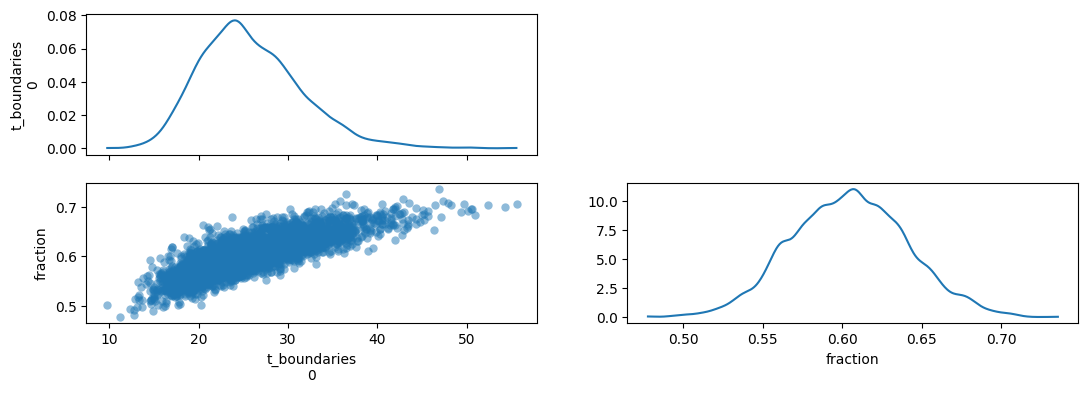

In [28]:
az.plot_pair(
    posterior_2epoch,
    var_names=["t_boundaries", "fraction"],
)

The posterior predictive checks show a much better absolute goodness of fit.

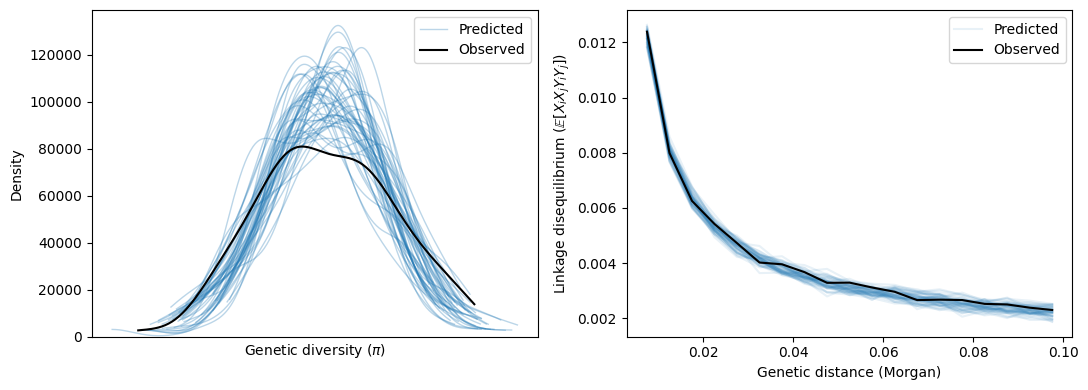

In [29]:
plot_posterior_predictive(posterior_2epoch);

Finally, we can visualise the trajectories implied by a few draws from the posterior (as we did with the prior). We have successfully recovered the true bottleneck.

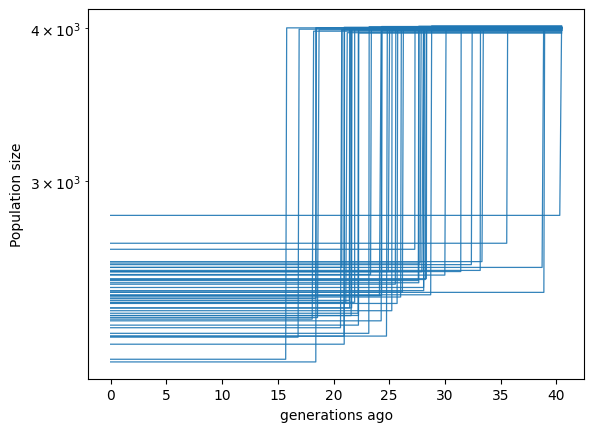

In [30]:
_samples = az.extract(posterior_2epoch, num_samples=50, random_seed=1)
two_epoch_model.plot_demography(_samples, color="C0");

## Fitting an exponential model

Because we are working with simulated data, we know that the true demography is a two-epoch piecewise constant. It is of interest, however, to see how other families would fit this case.

In [31]:
from bayesld.inference import PiecewiseExponential

Next, I fit a piecewise-exponential model, where the main difference is that I assume changes in $N_e$ happen in a continuous fashion.

$$
\begin{align}
N_a &\sim \text{LogNormal}(\log(10000), 1), \\
t_0 &\sim \text{LogNormal}(\log(100), 1), \\
\texttt{log\_alpha\_fold} &\sim \text{Normal}(0, 0.5), \\
N_c &= N_a \exp(\texttt{log\_alpha\_fold}), \\
\alpha &= \frac{\texttt{log\_alpha\_fold}}{t_0}, \\
N_e(t) &=
\begin{cases}
N_c \exp(-\alpha t), & t < t_0, \\
N_a, & t \geq t_0.
\end{cases}
\end{align}
$$

In [32]:
exp_model = (
    PiecewiseExponential()
    .with_data(
        mean_diversity=obs_pi,
        mean_ld=obs_ld,
        left_bins=left_bins_morgan,
        right_bins=right_bins_morgan,
        recombination_rate=recombination_rate,
        mutation_rate=mutation_rate,
        num_samples=num_samples,
        sequence_length=window_length_in_bp,
    )
    .with_prior(
        mu_log_ne_a=np.log(10_000),
        sigma_log_ne_a=1,
        mu_log_t=np.log(100),
        sigma_log_t=1,
        mu_log_alpha_fold=0.0,
        sigma_log_alpha_fold=0.5,
    )
)
exp_model

PiecewiseExponential(Quadrature nodes=8, Windows=100, LD bins=19, Samples=30 (ploidy 2), Sequence length=2e+07, Mutation rate=1e-08, Recombination rate=1e-08, Bias dataset=0, Covariance dataset=100+0)

We sample a few trajectories from the prior. Compared to the two-epoch piecewise constant model, this model forces the $N_e$ to be continuous. The chosen prior is still weakly informative, in the sense that it is “sceptical” to observing any change in $N_e$.

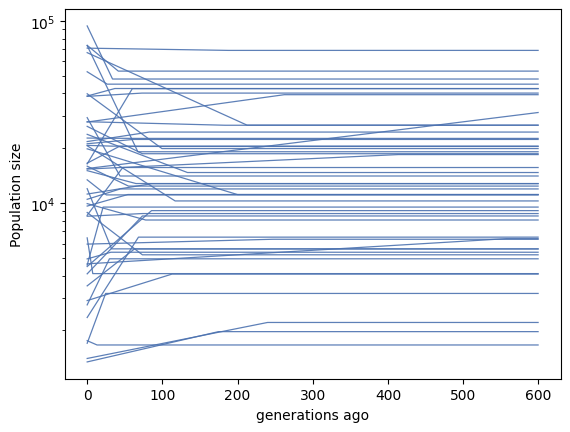

In [33]:
prior_exp = exp_model.sample_prior()
_samples = az.extract(prior_exp, num_samples=50, random_seed=1)
exp_model.plot_demography(_samples);

Let's repeat the fitting procedure.

In [34]:
%%time 
for i in range(4):
    exp_model = exp_model.active_learning_round(
        num_points=30,
        rtol=0.1,
        min_replicates=50,
        verbose=False,
        num_workers=8,
        seed=13576,
    )

CPU times: user 8.39 s, sys: 1.39 s, total: 9.78 s
Wall time: 11min 8s


In [35]:
posterior_exp = exp_model.sample(
    draws=1000, num_workers=4, chains=4, seed=32167, verbose=False
)

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

First, we check if the Markov chain has converged:

In [36]:
az.summary(
    posterior_exp,
    var_names=["Ne_c", "Ne_a", "t0", "log_alpha_fold"],
    kind="diagnostics",
)

,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Ne_c,2176,2537,1.00,4.2,3
Ne_a,7932,3006,1.00,0.1,0.069
t0,2214,2528,1.00,0.31,0.35
log_alpha_fold,2182,2521,1.00,0.0019,0.0014


The estimated decline fraction has not changed much, although confidence intervals have increased in width (reflecting higher uncertainty under this model).

In [37]:
posterior_exp["posterior"]["fraction"] = (
    posterior_exp["posterior"]["Ne_c"] / posterior_exp["posterior"]["Ne_a"]
)
az.summary(posterior_exp, var_names=["t0", "fraction", "Ne_a"], kind="stats")

,mean,sd,eti89_lb,eti89_ub
t0,53,14,33,79
fraction,0.56,0.049,0.48,0.64
Ne_a,4000,9,4000,4000


When the bottleneck started, however, is now overestimated compared to the actual demographic model. This is because in the true demography, the bottleneck happened instantaneously. Why this happens is perhaps more clear when we plot a bunch of draws from the fitted model.

<Axes: xlabel='generations ago', ylabel='Population size'>

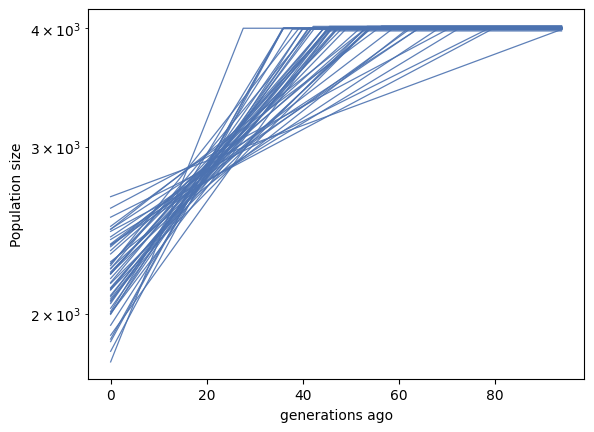

In [38]:
_samples = az.extract(posterior_exp, num_samples=50, random_seed=1)
exp_model.plot_demography(_samples)

Let's evaluate the absolute goodness of fit. In this case, the posterior predictive distribution is almost identical to the one from the two-epoch model. This means that it will be very hard (if not impossible) to distinguish between both demographic scenarios from the considered genetic data alone. We will discuss this again in a later section about model comparison.

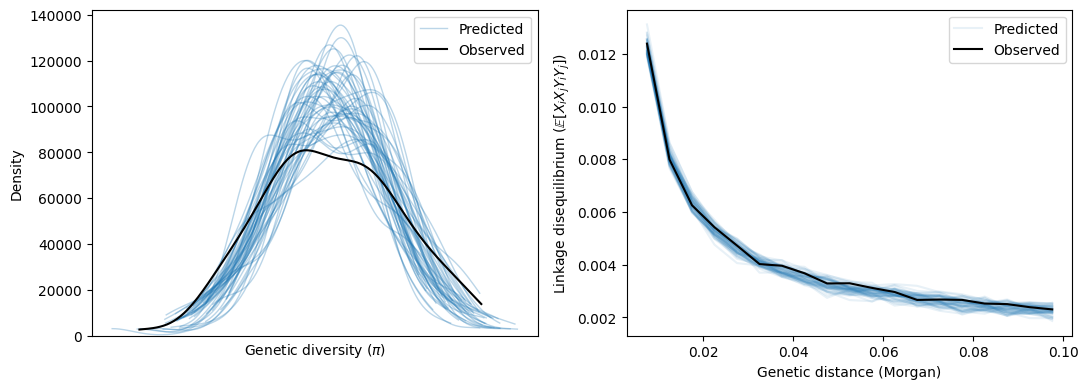

In [39]:
plot_posterior_predictive(posterior_exp);

## Fitting a random-walk

So far, we have fitted three models. The constant population size model was too simplistic and failed to explain well the data, whereas the two-epoch piecewise constant and piecewise-exponential model have equivalent complexity (i.e. same number of parameters to estimate) and provide equally good fits (at least, when eyeballing the posterior predictive distributions). We could consider ourselves satisfied, but this is a tutorial and it’s often helpful to consider more complex models than the final one to convince ourselves that adding more  complexity will not improve the fit.

`bayesld` offers a flexible "Random-walk" model where we allow $N_e$ to vary in a step-wise fashion across a predefined grid. Here, I chose a dense grid with 100 boundaries, which gives 101 epochs and allows changes every generation in the past 100 generations.

In [40]:
predefined_grid = np.arange(0, 101, 1)[1:]
predefined_grid

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

In this model, the prior serves the purpose of regularising the estimates. With 101 epochs, we would overfit without it. We use the prior to indicate that, unless the data strongly indicates otherwise, changes between epochs should be small. The amount of regularisation is controlled by the $\sigma_{\text{step}}$ prior scale.

$$
\begin{align}
\log N_{100} &\sim \text{Normal}(\log(10000), 1), \\
\texttt{steps}_i &\sim \text{Normal}(0, 0.05), \qquad i = 0, \ldots, 99, \\
\log N_i &= \log N_{100} + \sum_{j=i}^{99} \texttt{steps}_j, \qquad i = 0, \ldots, 99, \\
N_e(t) &= N_i \qquad \text{for } t \text{ in epoch } i,\quad i = 0, \ldots, 100.
\end{align}
$$

Let's instantiate the model:

In [41]:
from bayesld.inference import RandomWalk

walk_model = (
    RandomWalk(predefined_grid)
    .with_data(
        mean_diversity=obs_pi,
        mean_ld=obs_ld,
        left_bins=left_bins_morgan,
        right_bins=right_bins_morgan,
        recombination_rate=recombination_rate,
        mutation_rate=mutation_rate,
        num_samples=num_samples,
        sequence_length=window_length_in_bp,
    )
    .with_prior(mu_log_ne=np.log(10_000), sigma_log_ne=1, sigma_step=0.05)
)
walk_model

RandomWalk(Epochs=101, Grid=[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100.], Quadrature nodes=8, Windows=100, LD bins=19, Samples=30 (ploidy 2), Sequence length=2e+07, Mutation rate=1e-08, Recombination rate=1e-08, Bias dataset=0, Covariance dataset=100+0)

For this model, it would not make sense to look at a table with a 100s of parameters, and it might be difficult to have intuitions about the prior. Instead, we just sample from the prior and visualise it:

<Axes: xlabel='generations ago', ylabel='Population size'>

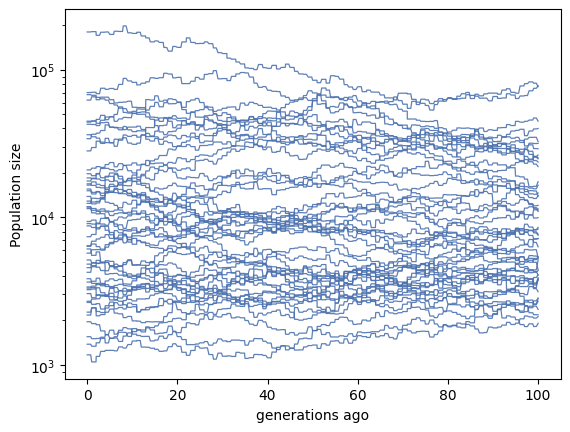

In [42]:
prior_walk = walk_model.sample_prior()
_samples = az.extract(prior_walk, num_samples=50, random_seed=1)
walk_model.plot_demography(_samples)

The $N_e$ trajectory seems mostly flat with a bit of wiggling. You may increase or decrease `sigma_step` and observe how the prior distribution changes. Let's continue with a value of 0.05 and repeat the fitting procedure. 

Caution: This model will take longer than the previous ones. The first warm-up iterations will be specially slow, but the algorithm should speed up after choosing an appropriate step size.

In [43]:
%%time 
for i in range(4):
    walk_model = walk_model.active_learning_round(
        num_points=30,
        rtol=0.1,
        min_replicates=50,
        verbose=False,
        num_workers=8,
        seed=13576,
    )

CPU times: user 46.9 s, sys: 3.11 s, total: 50 s
Wall time: 13min 36s


In [44]:
posterior_walk = walk_model.sample(
    draws=1000, num_workers=4, chains=4, seed=32167, verbose=False
)

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

One last time, we check that the MCMC has converged. With this many parameters, we can use a convergence diagnostic plot instead, in which all estimate variables are grouped together. We can see the MCMC fitted without problems.

/Users/curro/Documents/Dev/refactor/bayesld/.venv/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


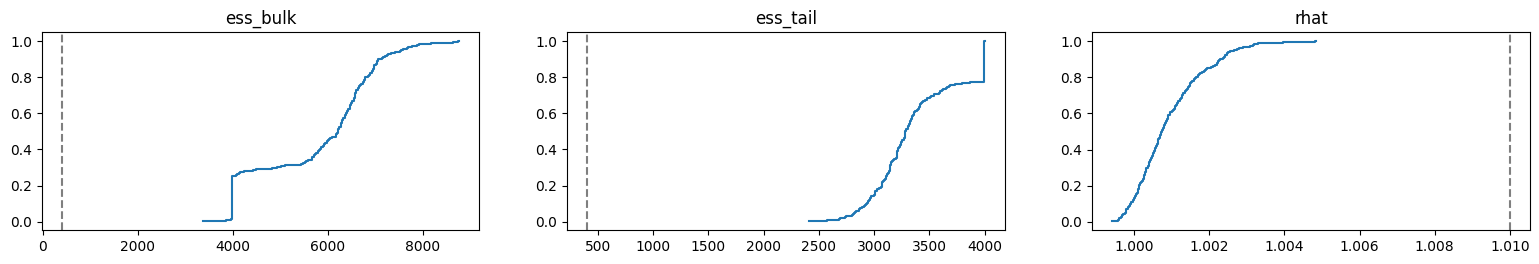

In [45]:
az.plot_convergence_dist(posterior_walk);

Once again, the estimated ratio between contemporary and ancient population size is consistent with the ground truth.

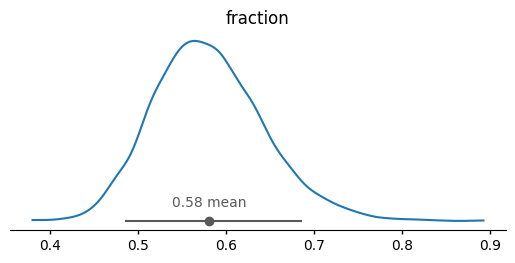

In [46]:
# Notice that the draws have 3-dimensions: chains, draws and number of epochs
_contemporary_ne = posterior_walk["posterior"]["Ne_values"][:, :, 0]
_ancient_ne = posterior_walk["posterior"]["Ne_values"][:, :, -1]
posterior_walk["posterior"]["fraction"] = _contemporary_ne / _ancient_ne
az.plot_dist(posterior_walk, var_names="fraction")

Despite having many more parameters, the absolute goodness-of-fit does not seem to have improved. Also, it doesn't seem to have overfitted thanks to the regularising prior (in the sense that its posterior predictive distribution is not worse than the two-epoch or exponential model).

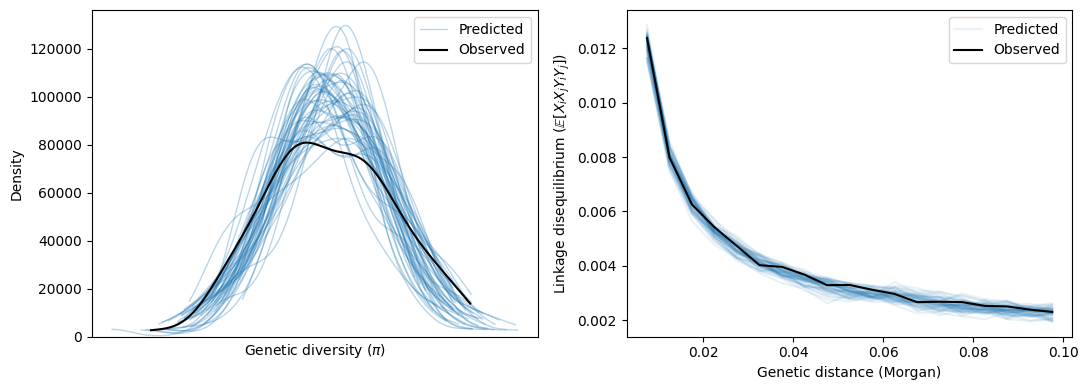

In [47]:
plot_posterior_predictive(posterior_walk);

For this model, looking at the table of parameters directly is not very informative. If we visualise the $N_e$ trajectories directly, we can observe that (1) the posterior is very different from the prior (we learned from data!) and (2) they are qualitatively very similar to the fitted exponential model. This is a good sign that we should not keep increasing the complexity of the models considered.

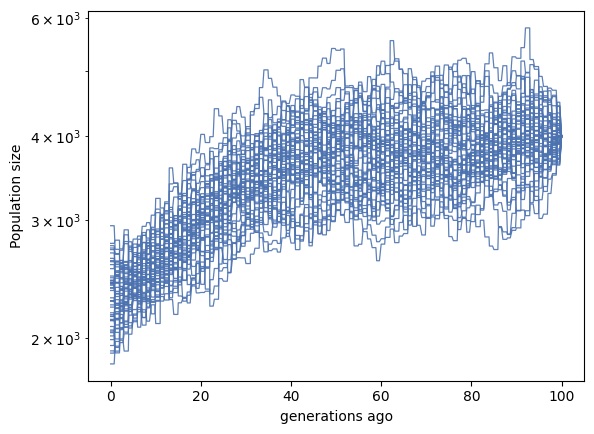

In [48]:
_samples = az.extract(posterior_walk, num_samples=50, random_seed=1)
walk_model.plot_demography(_samples);

## Saving output

I recommend saving the output to a `netcdf` for intercompatibility across languages and with the `ArViz` ecosystem.

In [49]:
import h5py

posterior_walk.to_netcdf("random_walk.nc", engine="h5netcdf")
posterior_exp.to_netcdf("exponential.nc", engine="h5netcdf")
posterior_2epoch.to_netcdf("two_epoch.nc", engine="h5netcdf")

In [50]:
az.from_netcdf("two_epoch.nc", engine="h5netcdf")

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:                (chain: 4, draw: 1000, epoch: 2, boundary: 1, bin: 19)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│         * epoch                  (epoch) int64 16B 0 1
│         * boundary               (boundary) int64 8B 0
│         * bin                    (bin) float64 152B 0.0075 0.0125 ... 0.0925 0.0975
│       Data variables:
│           log_Ne                 (chain, draw, epoch) float64 64kB ...
│           log_t                  (chain, draw, boundary) float64 32kB ...
│           Ne_values              (chain, draw, epoch) float64 64kB ...
│           t_boundaries           (chain, draw, boundary) float64 32kB ...
│           expected_pi            (chain, draw) float64 32kB ...
│           gp_bias_ld             (chain, draw, bin) float64 608kB ...
│           corrected_expected_ld  (chain, draw, bin) float64 608kB ...
│           fraction               (chain, draw) float64 32kB ...
├── Group: /sample_stats
│       Dimensions:          (chain: 4, draw: 1000)
│       Coordinates:
│         * chain            (chain) int64 32B 0 1 2 3
│         * draw             (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
│       Data variables:
│           lp               (chain, draw) float64 32kB ...
│           acceptance_rate  (chain, draw) float64 32kB ...
│           step_size        (chain, draw) float64 32kB ...
│           tree_depth       (chain, draw) int64 32kB ...
│           n_steps          (chain, draw) int64 32kB ...
│           diverging        (chain, draw) bool 4kB ...
│           energy           (chain, draw) float64 32kB ...
│       Attributes:
│           created_at:                 2026-07-11T10:44:07.018325+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          cmdstanpy
│           inference_library_version:  1.3.0
│           sample_dims:                ['chain', 'draw']
├── Group: /log_likelihood
│       Dimensions:  (chain: 4, draw: 1000, window: 100)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * window   (window) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
│       Data variables:
│           log_lik  (chain, draw, window) float64 3MB ...
├── Group: /posterior_predictive
│       Dimensions:      (chain: 4, draw: 1000, window: 100, bin: 19)
│       Coordinates:
│         * chain        (chain) int64 32B 0 1 2 3
│         * draw         (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
│         * window       (window) int64 800B 0 1 2 3 4 5 6 7 ... 92 93 94 95 96 97 98 99
│         * bin          (bin) float64 152B 0.0075 0.0125 0.0175 ... 0.0925 0.0975
│       Data variables:
│           observed_pi  (chain, draw, window) float64 3MB ...
│           observed_ld  (chain, draw, window, bin) float64 61MB ...
│           mean_pi      (chain, draw) float64 32kB ...
│           mean_ld      (chain, draw, bin) float64 608kB ...
├── Group: /observed_data
│       Dimensions:      (window: 100, bin: 19)
│       Coordinates:
│         * window       (window) int64 800B 0 1 2 3 4 5 6 7 ... 92 93 94 95 96 97 98 99
│         * bin          (bin) float64 152B 0.0075 0.0125 0.0175 ... 0.0925 0.0975
│       Data variables:
│           observed_pi  (window) float64 800B ...
│           observed_ld  (window, bin) float64 15kB ...
│           mean_pi      float64 8B ...
│           mean_ld      (bin) float64 152B ...
└── Group: /constant_data
        Dimensions:   (bin: 19)
        Coordinates:
          * bin       (bin) float64 152B 0.0075 0.0125 0.0175 ... 0.0875 0.0925 0.0975
        Data variables:
            left      (bin) float64 1

# Advanced topics

Up to here, the tutorial gives an overview of the model-based inference framework behind `bayesld`. 

Next, I digress a bit into (1) posterior predictive checks, (2) model comparison, and (3) assessing model convergence.

## Approximate posterior predictive checks

Earlier, I said we were doing posterior predictive checks. Being precise, we were doing "approximate" posterior predictive checks under the surrogate likelihood we jointly learn with the demography. If the fitted model has failed to accurately learn the likelihood, the approximate posterior predictive checks are unreliable. 

Instead, we would ideally do posterior predictive checks with actual coalescent simulations (via `msprime`). The drawback is obvious: it's much slower and it might be impractical at an early modelling stage. 

Next, I do a posterior predictive check with actual coalescent simulations. Notice we can use the `.to_msprime_demography` to obtain a `msprime` demographic object directly.

In [51]:
# Sample 50 draws from each fitted posterior
ms_samples = {
    "constant": az.extract(posterior_constant, num_samples=50, random_seed=1),
    "two_epoch": az.extract(posterior_2epoch, num_samples=50, random_seed=1),
    "exponential": az.extract(posterior_exp, num_samples=50, random_seed=1),
    "walk": az.extract(posterior_walk, num_samples=50, random_seed=1),
}
# Get a list of demographic objects
ms_demography = {
    "constant": constant_model.to_msprime_demography(ms_samples["constant"]),
    "two_epoch": two_epoch_model.to_msprime_demography(ms_samples["two_epoch"]),
    "exponential": exp_model.to_msprime_demography(ms_samples["exponential"]),
    "walk": walk_model.to_msprime_demography(ms_samples["walk"]),
}

Let's define a small helper function to simulate the different datasets:

In [52]:
%%time
def msprime_sim(demos, random_seed):
    for i, demo in enumerate(demos):
        yield bayesld.sim_sufficient_stats(
            demography=demo,
            samples=num_samples,
            left_bins=left_bins_morgan,
            right_bins=right_bins_morgan,
            mutation_rate=mutation_rate,
            recombination_rate=recombination_rate,
            sequence_length=window_length_in_bp,
            random_seed=random_seed+i,
            num_workers=8,
            num_replicates=num_windows,
        )

ms_ppc = {name : list(msprime_sim(demos, random_seed = 23576)) for name, demos in ms_demography.items()}

CPU times: user 14.7 s, sys: 2.97 s, total: 17.6 s
Wall time: 26min 11s


And plot the posterior predictive simulations together with the observed data:

In [53]:
def msprime_posterior_predictive(
    simulations_by_model,
    observed_pi,
    observed_ld,
    midpoints,
    color_obs="black",
):
    fig, (ax_pi, ax_ld) = plt.subplots(1, 2, figsize=(11, 4))
    palette = dict(
        zip(
            simulations_by_model.keys(),
            sns.color_palette(n_colors=len(simulations_by_model)),
        )
    )

    for name, simulations in simulations_by_model.items():
        color = palette[name]
        for i, (pi, _) in enumerate(simulations):
            sns.kdeplot(
                pi,
                color=color,
                alpha=0.3,
                linewidth=1,
                ax=ax_pi,
                label=name if i == 0 else None,
            )
    sns.kdeplot(
        observed_pi,
        color=color_obs,
        linewidth=1.5,
        ax=ax_pi,
        label="Observed",
    )
    ax_pi.legend()
    ax_pi.set_xlabel(r"Genetic diversity ($\pi$)")

    for name, simulations in simulations_by_model.items():
        color = palette[name]
        for i, (_, ld) in enumerate(simulations):
            ax_ld.plot(
                midpoints,
                ld.mean(axis=0),
                alpha=0.1,
                color=color,
                label=name if i == 0 else None,
            )
    ax_ld.plot(
        midpoints,
        observed_ld.mean(axis=0),
        color=color_obs,
        linewidth=1.5,
        label="Observed",
    )
    ax_ld.set_xlabel("Genetic distance (Morgan)")
    ax_ld.set_ylabel(r"Linkage disequilibrium ($\mathbb{E}[X_i X_j Y_i Y_j]$)")
    ax_ld.legend()

    fig.tight_layout()
    return fig

Overall, it seems like all models but the constant model predict the data reasonably well.

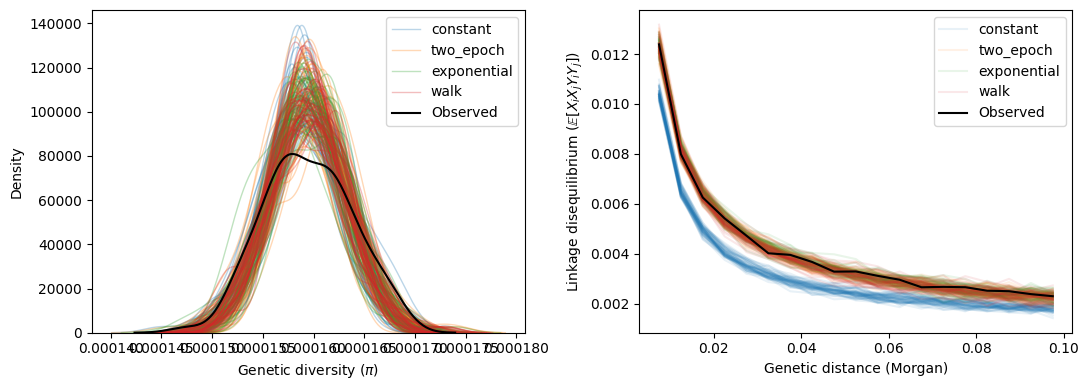

In [54]:
msprime_posterior_predictive(ms_ppc, obs_pi, obs_ld, midpoints);

## Model comparison and model stacking

So far, we have three different and competent models. In Bayesian inference, the prior often regularises the estimates, and therefore fitting a rich model might be a good idea. In this case, it depends on the _a priori_ knowledge. If we have external evidence that the reason for the bottleneck was indeed abrupt (caused by a founder event or a catastrophic event), it will be sub-optimal to use a model that penalises abrupt changes (random walk) or even worse, completely disables it (the exponential model). 

Still, we may want to choose one model. The msprime posterior predictive checks above are one way to compare their absolute goodness of fit.

## Model convergence

Assessing convergence in Bayesian inference is typically done by running different independent chains in parallel. However, as we pointed out before, `bayesld` jointly learns the surrogate likelihood via a sequence of active-learning rounds. One way to determine whether we have successfully learned the surrogate likelihood is to compare completely independent inferences over the same dataset. 

Hopefully, it should be easy enough to repeat the inference processes with different random seeds and later combine the output in a single chain. 

Let's define a final model:

In [55]:
final_model = PiecewiseConstant(num_epochs=2).with_data(
    mean_diversity=obs_pi,
    mean_ld=obs_ld,
    left_bins=left_bins_morgan,
    right_bins=right_bins_morgan,
    recombination_rate=recombination_rate,
    mutation_rate=mutation_rate,
    num_samples=num_samples,
    sequence_length=window_length_in_bp,
)

In [56]:
def run_inference(model, seed):
    for i in range(4):
        model = model.active_learning_round(
            num_points=30,
            rtol=0.1,
            min_replicates=50,
            verbose=False,
            num_workers=8,
            seed=seed,
        )
    return model.sample(draws=1000, chains=1, seed=seed, verbose=False)


_idata1 = run_inference(final_model, seed=32617)
_idata2 = run_inference(final_model, seed=9878)

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

In [57]:
# Small helper function to concatenate chains from independent runs
def concat_chains(*idatas):
    import xarray as xr

    out = idatas[0]
    for other in idatas[1:]:
        n = out["posterior"].sizes["chain"]
        other = other.map_over_datasets(
            lambda ds: (
                ds.assign_coords(chain=ds.chain + n) if "chain" in ds.dims else ds
            )
        )
        out = xr.map_over_datasets(
            lambda x, y: xr.concat([x, y], "chain") if "chain" in x.dims else x,
            out,
            other,
        )
    return out


idata = concat_chains(_idata1, _idata2)

In this case, we can assess that both independent chains appear to have converged.

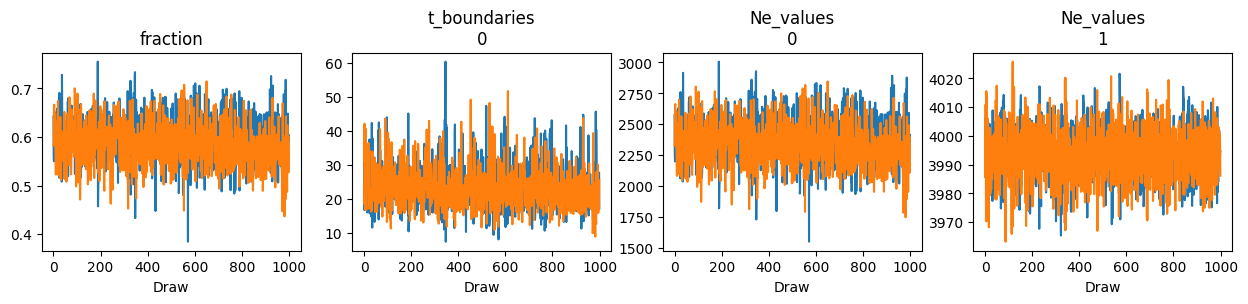

In [65]:
idata["posterior"]["fraction"] = idata["posterior"]["Ne_values"][:, :, 0] /  idata["posterior"]["Ne_values"][:, :, -1]
az.plot_trace(idata, var_names=["fraction", "t_boundaries", "Ne_values"]);

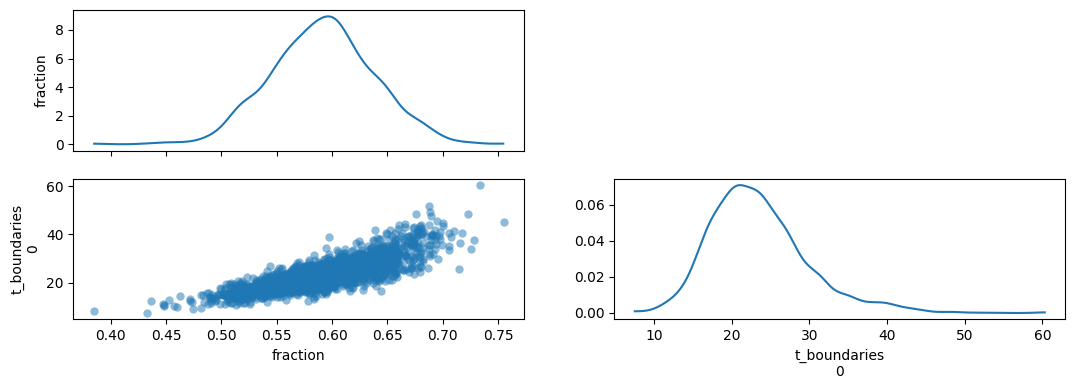

In [69]:
az.plot_pair(idata, var_names=["fraction", "t_boundaries"]);